# 01 — Pré-processamento, EDA e independência das partições

Entrada: Titulo + Noticia + Autor; Classe: 0 = Fake, 1 = Real. Base original sem revisão manual integral. Sinais de checagem e autoria não são certificados. Execute 01 → 02 → 03.

Antes da separação, usa somente texto e metadados para identificar candidatos a duplicatas próximas e formar grupos. O HashingVectorizer tem representação fixa: não aprende vocabulário ou IDF na base completa. Esta triagem não é o TF-IDF do modelo, que permanece dentro das dobras do 02. Nenhuma métrica de predição do holdout é usada para escolher a separação.

A EDA detalhada, os exemplos e as associações com rótulos são calculados somente no treino. O holdout recebe apenas verificações estruturais. Os grupos de semelhança são aproximações, não eventos confirmados. Se o holdout anterior já foi observado, uma nova divisão da mesma base não restaura sua independência como teste final.


In [1]:
from pathlib import Path
import sys
for base in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    module_dir = base / "notebooks/v2_validacao_externa"
    if (module_dir / "pipeline_utils.py").is_file():
        sys.path.insert(0, str(module_dir))
        break
else:
    raise FileNotFoundError("Execute dentro do projeto.")
import importlib
import pipeline_utils
importlib.reload(pipeline_utils)
from pipeline_utils import (project_root, compose_text, normalize_text, validate_labels,
                            sha256_file, load_bundle, LABEL_NAMES, SCHEMA_VERSION, MODEL_RELATIVE,
                            INPUT_POLICY, FEATURE_COLUMNS, checking_signals,
                            TRAIN_COLUMNS, PROCESSED_COLUMNS, EXTERNAL_COLUMNS,
                            validate_schema, make_features, prepare_authors)
ROOT = project_root()
DATA_DIR = ROOT / "notebooks/v2_validacao_externa/data/processed/texto_autor_exploratorio_v4"
import json
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt
from urllib.parse import urlsplit
from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import GroupShuffleSplit
from IPython.display import Markdown, display

REPORT_DIR = ROOT / "reports/v2_stacking_texto_autor_exploratorio/preproc_eda"
GRAPH_DIR = REPORT_DIR / "graficos"
GRAPH_DIR.mkdir(parents=True, exist_ok=True)
SEED = 42
TEST_SIZE = 0.2
# Fixe estas opções antes de observar métricas do holdout.
SPLIT_MODE = "similaridade"  # similaridade, fonte, evento ou periodo
SOURCE_COLUMN = "URL"
DATE_COLUMN = "Data"
EVENT_COLUMN = None  # Nome exato de uma coluna de eventos previamente identificados.
SIMILARITY_THRESHOLD = 0.90
N_NEIGHBORS = 6
BATCH_SIZE = 128


def salvar_grafico(fig, nome):
    fig.tight_layout()
    for extensao in ["png", "svg"]:
        fig.savefig(GRAPH_DIR / f"{nome}.{extensao}", dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def ausente(serie):
    return serie.isna() | serie.fillna("").astype(str).str.strip().eq("")


## 1. Esquema, qualidade e metadados

Colunas obrigatórias: Titulo, Noticia, Autor e Classe. Metadados URL, Data e evento são usados apenas para auditoria e separação. Não entram nas features. Registros sem corpo ou rótulo são excluídos e contabilizados. Duplicatas normalizadas com rótulos divergentes interrompem a execução.


In [2]:
RAW_PATH = ROOT / "data/FakeRecogna.xlsx"
df_raw = pd.read_excel(RAW_PATH)
validate_schema(df_raw, TRAIN_COLUMNS, context="dataset original")
df = df_raw.dropna(subset=["Noticia", "Classe"]).copy()
df["label"] = validate_labels(df["Classe"])
df["id_original"] = df.index
df["texto"] = compose_text(df)
df["texto_normalizado"] = df["texto"].map(normalize_text)
df = df[df["Noticia"].astype(str).str.strip().ne("") & df["texto_normalizado"].ne("")].copy()
conflicts = df.groupby("texto_normalizado")["label"].nunique()
if conflicts.gt(1).any():
    raise ValueError("Textos normalizados com rótulos conflitantes; corrija antes de separar.")
df = df.drop_duplicates("texto_normalizado").copy()
if df.empty or set(df.label) != {0, 1}:
    raise ValueError("A base precisa conter textos válidos de ambas as classes.")
print("EXPERIMENTO EXPLORATÓRIO: sem revisão manual integral de texto e autoria.")
print({"entrada": len(df_raw), "retidos": len(df), "classes": df.label.value_counts().to_dict()})

df = df.reset_index(drop=True)
qualidade: dict[str, int | str | bool] = {"registros_originais": len(df_raw), "registros_retidos": len(df),
             "removidos_ausentes_vazios_ou_duplicatas": len(df_raw) - len(df)}


def extrair_fonte(value):
    if pd.isna(value) or not str(value).strip():
        return ""
    text = str(value).strip()
    try:
        parsed = urlsplit(text if "://" in text else "https://" + text)
        host = (parsed.hostname or "").casefold().removeprefix("www.")
    except ValueError:
        return ""
    return host if "." in host else ""


df["fonte_auditoria"] = df[SOURCE_COLUMN].map(extrair_fonte) if SOURCE_COLUMN in df else ""
if DATE_COLUMN in df:
    # Formato brasileiro; valores não interpretáveis permanecem ausentes.
    df["data_auditoria"] = pd.to_datetime(df[DATE_COLUMN], errors="coerce", dayfirst=True, utc=True)
else:
    df["data_auditoria"] = pd.NaT
if EVENT_COLUMN is not None:
    validate_schema(df, [EVENT_COLUMN], context="metadado de evento")
    df["evento_auditoria"] = df[EVENT_COLUMN].fillna("").astype(str).str.strip()
else:
    df["evento_auditoria"] = ""
print("Metadados disponíveis:", {"fonte": SOURCE_COLUMN in df, "data": DATE_COLUMN in df,
                                  "evento_configurado": EVENT_COLUMN})


EXPERIMENTO EXPLORATÓRIO: sem revisão manual integral de texto e autoria.
{'entrada': 11903, 'retidos': 11902, 'classes': {0: 5951, 1: 5951}}
Metadados disponíveis: {'fonte': True, 'data': True, 'evento_configurado': None}


## 2. Textos semelhantes e candidatos ao mesmo evento

Compara os seis vizinhos mais próximos de cada texto com cosseno em unigramas/bigramas normalizados. Conecta pares com similaridade ≥ 0,90, sem consultar o rótulo. Componentes conexos formam grupos conservadores para a separação.

É uma triagem limitada aos vizinhos consultados: pode omitir paráfrases, eventos descritos de formas diferentes e pares em grupos muito densos. Colisões do hashing e vocabulário editorial podem produzir falsos positivos. A sobreposição dos termos de título ajuda a localizar possíveis eventos, mas não confirma identidade factual. Não há aprovação manual obrigatória.


In [3]:
hashing = HashingVectorizer(n_features=2**18, alternate_sign=False, norm="l2",
                           preprocessor=normalize_text, lowercase=False, ngram_range=(1, 2))
matrix = csr_matrix(hashing.transform(df.texto))
if (matrix.getnnz(axis=1) == 0).any():
    raise ValueError("Texto sem tokens para a triagem de similaridade.")
neighbors = NearestNeighbors(n_neighbors=min(N_NEIGHBORS, len(df)), metric="cosine",
                             algorithm="brute", n_jobs=1).fit(matrix)
pais = np.arange(len(df))


def raiz(i):
    while pais[i] != i:
        pais[i] = pais[pais[i]]
        i = pais[i]
    return int(i)


def unir(i, j):
    a, b = raiz(i), raiz(j)
    if a != b:
        pais[max(a, b)] = min(a, b)


pares = {}
for inicio in range(0, len(df), BATCH_SIZE):
    fim = min(inicio + BATCH_SIZE, len(df))
    distances, indices = neighbors.kneighbors(matrix[inicio:fim])
    for offset, (dists, ids) in enumerate(zip(distances, indices)):
        i = inicio + offset
        for distance, j in zip(dists, ids):
            j = int(j)
            score = float(1 - distance)
            if i == j or score < SIMILARITY_THRESHOLD:
                continue
            a, b = sorted([i, j])
            pares[(a, b)] = max(score, pares.get((a, b), 0.0))
            unir(a, b)
df["grupo_similaridade"] = [raiz(i) for i in range(len(df))]
pares_df = pd.DataFrame([{"indice_a": a, "indice_b": b, "similaridade": score}
                         for (a, b), score in pares.items()],
                        columns=["indice_a", "indice_b", "similaridade"])
print("Pares candidatos:", len(pares_df), "Grupos:", df.grupo_similaridade.nunique())


Pares candidatos: 164 Grupos: 11788


## 3. Avaliação estrutural das opções de separação

A opção padrão mantém os grupos de similaridade juntos. Fonte/evento também unem os textos semelhantes antes de dividir. Datas usam as notícias mais recentes como holdout, sem cortar empates de data; componentes de similaridade que atravessam a fronteira são removidos do treino.

Fonte exige URLs válidas em todos os registros; evento exige uma coluna explicitamente configurada e preenchida; período exige datas interpretáveis em todos os registros. Sem essas condições, a opção fica indisponível e não há fallback silencioso. O relatório compara viabilidade e sobreposição, sem treinar modelos ou escolher pela performance. Um único sorteio por grupos pode resultar em classes desbalanceadas.


In [4]:
def grupos_com_metadado(coluna):
    # Une componentes de similaridade que compartilham fonte/evento.
    representantes = {}
    for i, valor in enumerate(df[coluna]):
        if valor in representantes:
            unir(i, representantes[valor])
        else:
            representantes[valor] = i
    return np.array([raiz(i) for i in range(len(df))])


def separar(modo):
    global pais
    pais = df.grupo_similaridade.to_numpy().copy()
    removidos = 0
    if modo == "periodo":
        if df.data_auditoria.isna().any():
            raise ValueError("Período exige datas válidas em todos os registros.")
        ordenadas = df.data_auditoria.sort_values()
        corte = ordenadas.iloc[min(int(len(df) * (1 - TEST_SIZE)), len(df) - 1)]
        idx_test = np.flatnonzero(df.data_auditoria.ge(corte))
        idx_train = np.flatnonzero(df.data_auditoria.lt(corte))
        grupos_test = set(df.iloc[idx_test].grupo_similaridade)
        manter = ~df.iloc[idx_train].grupo_similaridade.isin(grupos_test).to_numpy()
        removidos = int((~manter).sum())
        idx_train = idx_train[manter]
    else:
        if modo == "similaridade":
            grupos = df.grupo_similaridade.to_numpy()
        elif modo in {"fonte", "evento"}:
            coluna = "fonte_auditoria" if modo == "fonte" else "evento_auditoria"
            if df[coluna].eq("").any():
                raise ValueError(f"{modo}: metadado ausente ou inválido em parte da base.")
            grupos = grupos_com_metadado(coluna)
        else:
            raise ValueError("SPLIT_MODE deve ser similaridade, fonte, evento ou periodo.")
        if len(set(grupos)) < 2:
            raise ValueError("Menos de dois grupos independentes para separar.")
        splitter = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=SEED)
        idx_train, idx_test = next(splitter.split(df, groups=grupos))
    if not len(idx_train) or not len(idx_test):
        raise ValueError("Partição vazia.")
    if set(df.iloc[idx_train].label) != {0, 1} or set(df.iloc[idx_test].label) != {0, 1}:
        raise ValueError("A separação não preservou ambas as classes nas duas partições.")
    return idx_train, idx_test, removidos


avaliacoes = []
for modo in ["similaridade", "fonte", "evento", "periodo"]:
    try:
        a, b, removidos = separar(modo)
        esquerda, direita = df.iloc[a], df.iloc[b]
        avaliacoes.append({"modo": modo, "viavel": True, "motivo": "",
            "n_treino": len(a), "n_holdout": len(b), "removidos_fronteira": removidos,
            "grupos_similares_compartilhados": len(set(esquerda.grupo_similaridade) & set(direita.grupo_similaridade)),
            "fontes_compartilhadas": len((set(esquerda.fonte_auditoria) & set(direita.fonte_auditoria)) - {""}),
            "autores_compartilhados": len((set(prepare_authors(esquerda).ravel()) &
                                            set(prepare_authors(direita).ravel())) - {"autor_desconhecido"})})
    except ValueError as erro:
        avaliacoes.append({"modo": modo, "viavel": False, "motivo": str(erro)})
avaliacoes = pd.DataFrame(avaliacoes)
display(avaliacoes)
avaliacoes.to_csv(REPORT_DIR / "avaliacao_estrutural_separacoes.csv", index=False)
idx_train, idx_holdout, removidos_fronteira = separar(SPLIT_MODE)
train, holdout = df.iloc[idx_train].copy(), df.iloc[idx_holdout].copy()
if not set(train.texto_normalizado).isdisjoint(holdout.texto_normalizado):
    raise ValueError("Duplicata exata entre as partições.")
if not set(train.grupo_similaridade).isdisjoint(holdout.grupo_similaridade):
    raise ValueError("Grupo de similaridade compartilhado entre as partições.")
print("Separação escolhida antes da avaliação:", SPLIT_MODE)


,modo,viavel,motivo,n_treino,n_holdout,removidos_fronteira,grupos_similares_compartilhados,fontes_compartilhadas,autores_compartilhados
0,similaridade,True,,9518.0,2384.0,0.0,0.0,13.0,219.0
1,fonte,True,,9289.0,2613.0,0.0,0.0,0.0,5.0
2,evento,False,evento: metadado ausente ou inválido em parte ...,NaN,NaN,NaN,NaN,NaN,NaN
3,periodo,False,Período exige datas válidas em todos os regist...,NaN,NaN,NaN,NaN,NaN,NaN


Separação escolhida antes da avaliação: similaridade


## 4. Valores ausentes por classe — somente treino

Conta valores nulos e strings vazias. Datas no campo Autor são diagnosticadas separadamente e tratadas como autoria desconhecida pelo pipeline. A URL representa a fonte de coleta/checagem, que pode diferir da fonte original da alegação.


,label,classe,coluna,ausentes,total,proporcao
0,0,Fake,Titulo,26,4752,0.005471
1,0,Fake,Noticia,0,4752,0.000000
2,0,Fake,Autor,0,4752,0.000000
3,0,Fake,URL,0,4752,0.000000
4,0,Fake,Data,288,4752,0.060606
5,0,Fake,Categoria,0,4752,0.000000
6,1,Real,Titulo,0,4766,0.000000
7,1,Real,Noticia,0,4766,0.000000
8,1,Real,Autor,133,4766,0.027906
9,1,Real,URL,0,4766,0.000000


fontes_ausentes_ou_invalidas_treino       0
datas_ausentes_ou_invalidas_treino     7339
eventos_ausentes_treino                9518
Name: registros, dtype: int64

,autor_ausente,autor_data
label,,
0,0.000000,0.024200
1,0.027906,0.466219


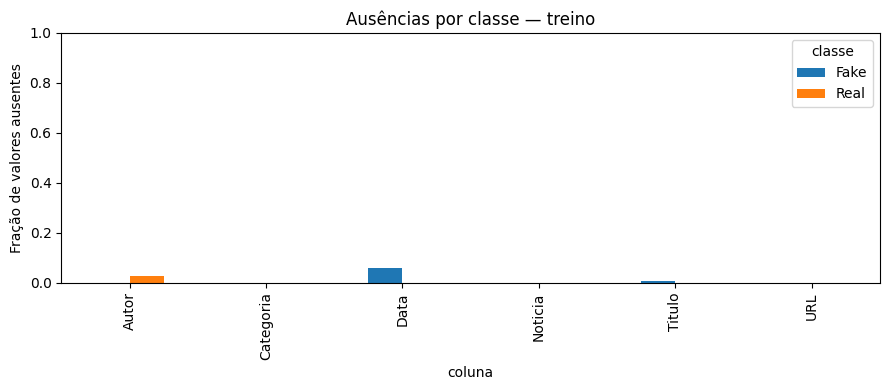

In [5]:
colunas_auditoria = FEATURE_COLUMNS + [c for c in ["URL", "Data", "Categoria"] if c in train]
ausencias = []
for label in [0, 1]:
    grupo = train.loc[train["label"].eq(label)]
    for coluna in colunas_auditoria:
        n = len(grupo.loc[ausente(grupo[coluna])])
        ausencias.append({"label": label, "classe": LABEL_NAMES[label], "coluna": coluna,
                          "ausentes": n, "total": len(grupo), "proporcao": n / len(grupo)})
ausencias = pd.DataFrame(ausencias)
ausencias.to_csv(REPORT_DIR / "ausentes_por_classe.csv", index=False)
display(ausencias)
qualidade_metadados = {
    "fontes_ausentes_ou_invalidas_treino": len(train.loc[train.fonte_auditoria.eq("")]),
    "datas_ausentes_ou_invalidas_treino": len(train.loc[train.data_auditoria.isna()]),
    "eventos_ausentes_treino": len(train.loc[train.evento_auditoria.eq("")]),
}
display(pd.Series(qualidade_metadados, name="registros"))
(REPORT_DIR / "qualidade_metadados_treino.json").write_text(
    json.dumps(qualidade_metadados, indent=2, ensure_ascii=False), encoding="utf-8")
auditoria = train[["id_original", "label", "fonte_auditoria", "grupo_similaridade"]].copy()
auditoria["autor_normalizado"] = prepare_authors(train).ravel()
auditoria["palavras"] = train.texto.map(lambda text: len(normalize_text(text).split()))
auditoria["pistas_editoriais"] = train.texto.map(lambda text: " | ".join(checking_signals(text)))
auditoria["autor_ausente"] = ausente(train.Autor)
auditoria["autor_data"] = train.Autor.fillna("").astype(str).str.contains(
    r"\b\d{1,2}/\d{1,2}/\d{2,4}\b", regex=True)
auditoria.to_csv(REPORT_DIR / "auditoria_treino.csv", index=False)
display(auditoria.groupby("label")[["autor_ausente", "autor_data"]].mean())
fig, ax = plt.subplots(figsize=(9, 4))
tabela_ausencias = ausencias.pivot(index="coluna", columns="classe", values="proporcao")
tabela_ausencias.plot.bar(ax=ax)
ax.set_ylabel("Fração de valores ausentes")
ax.set_ylim(0, 1)
ax.set_title("Ausências por classe — treino")
salvar_grafico(fig, "01_ausencias")


## 5. Classes, comprimentos e sinais de checagem — somente treino

Termos sinalizados são indícios contextuais, não vereditos de contaminação. Nenhum termo é removido automaticamente.


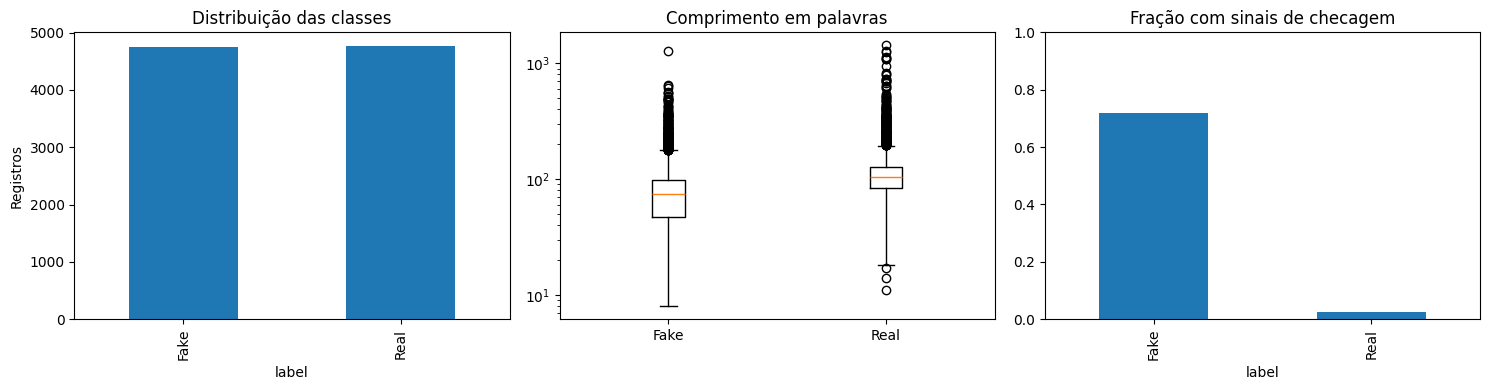

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
train.label.value_counts().reindex([0, 1], fill_value=0).rename(index=LABEL_NAMES).plot.bar(ax=axes[0])
axes[0].set_title("Distribuição das classes")
axes[0].set_ylabel("Registros")
axes[1].boxplot([auditoria.loc[auditoria.label.eq(k), "palavras"] for k in [0, 1]])
axes[1].set_xticks([1, 2], ["Fake", "Real"])
axes[1].set_yscale("log")
axes[1].set_title("Comprimento em palavras")
auditoria.assign(sinal=auditoria.pistas_editoriais.ne("")).groupby("label").sinal.mean().rename(
    index=LABEL_NAMES).plot.bar(ax=axes[2])
axes[2].set_ylim(0, 1)
axes[2].set_title("Fração com sinais de checagem")
salvar_grafico(fig, "02_distribuicoes")


## 6. Concentração e associação de autores/fontes com os rótulos

Exporta contagens, proporções Fake/Real e concentração das dez identidades mais frequentes. Categorias pequenas podem parecer puras por acaso; pureza não prova vazamento nem causalidade. Autoria desconhecida permanece na tabela para permitir diagnosticar sua associação com a classe. A fonte extraída é o domínio da URL disponível.


,Fake,Real,total,fracao_fake,fracao_real,pureza_descritiva
autor_normalizado,,,,,,
autor_desconhecido,115,2355,2470,0.046559,0.953441,0.953441
edgard matsuki,1194,0,1194,1.000000,0.000000,1.000000
kyene becker,485,0,485,1.000000,0.000000,1.000000
por g1,187,251,438,0.426941,0.573059,0.573059
gilmar lopes,420,0,420,1.000000,0.000000,1.000000
comprova,307,0,307,1.000000,0.000000,1.000000
"por roney domingos, g1",243,0,243,1.000000,0.000000,1.000000
afp brasil,233,0,233,1.000000,0.000000,1.000000
marco faustino,225,0,225,1.000000,0.000000,1.000000


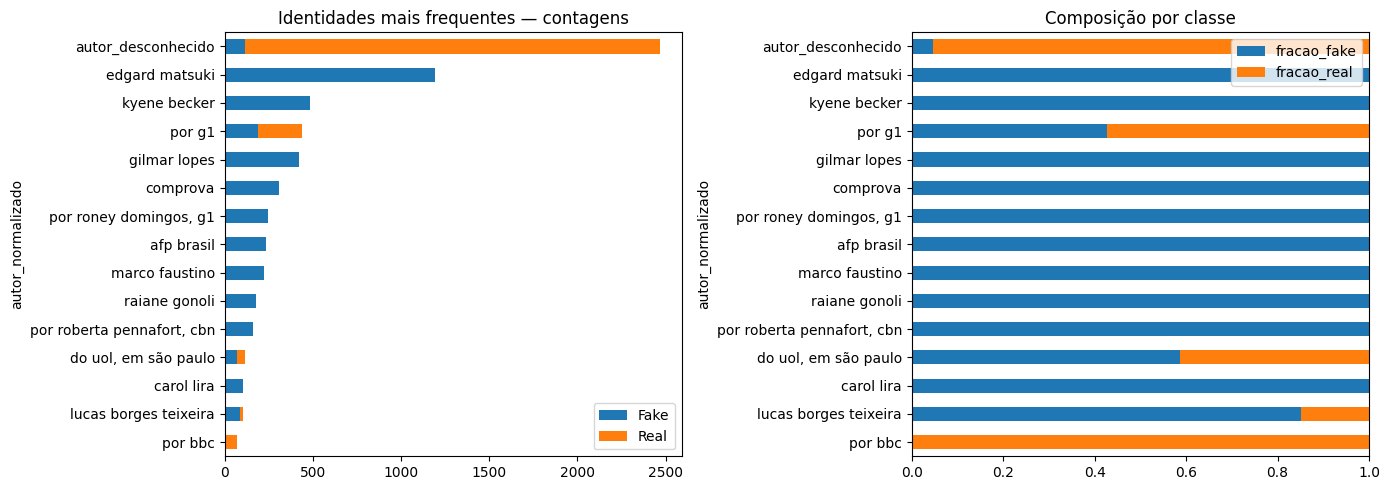

,Fake,Real,total,fracao_fake,fracao_real,pureza_descritiva
fonte_auditoria,,,,,,
noticias.uol.com.br,476,2752,3228,0.147460,0.852540,0.852540
boatos.org,1989,0,1989,1.000000,0.000000,1.000000
g1.globo.com,945,892,1837,0.514426,0.485574,0.514426
e-farsas.com,645,0,645,1.000000,0.000000,1.000000
uol.com.br,0,391,391,0.000000,1.000000,1.000000
checamos.afp.com,390,0,390,1.000000,0.000000,1.000000
projetocomprova.com.br,307,0,307,1.000000,0.000000,1.000000
economia.uol.com.br,0,240,240,0.000000,1.000000,1.000000
extra.globo.com,0,174,174,0.000000,1.000000,1.000000


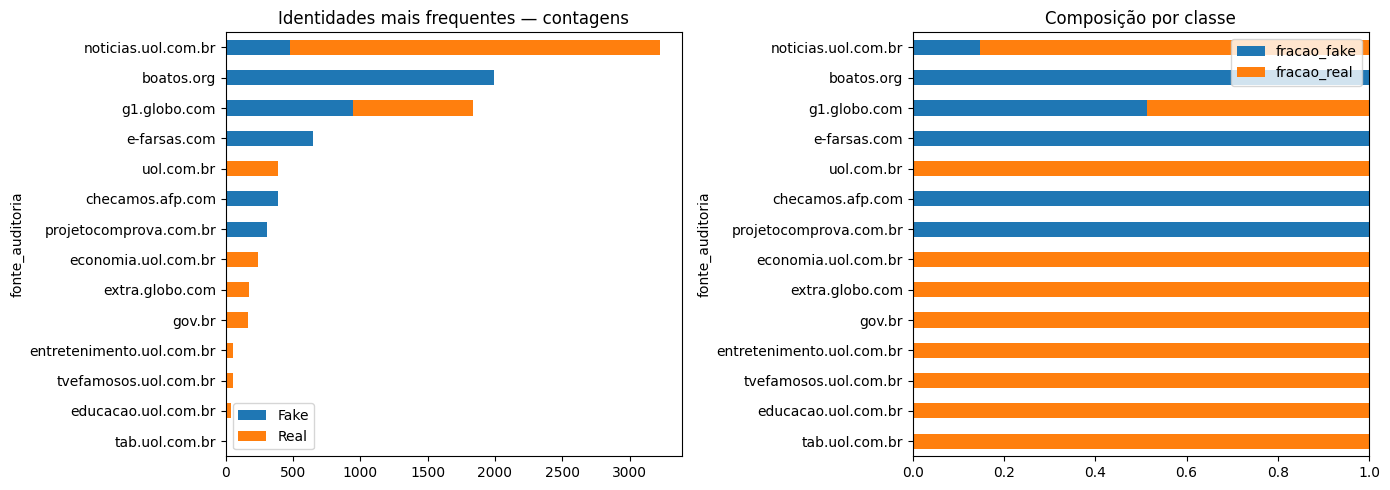

,campo,identidades,fracao_top1,fracao_top10
0,autor_normalizado,1272,0.259508,0.650662
1,fonte_auditoria,14,0.339147,0.984345


In [7]:
concentracao = []
for coluna in ["autor_normalizado", "fonte_auditoria"]:
    valores = auditoria[coluna].replace("", "fonte_desconhecida")
    tabela = pd.crosstab(valores, auditoria.label).reindex(columns=[0, 1], fill_value=0)
    tabela.columns = ["Fake", "Real"]
    tabela["total"] = tabela.Fake + tabela.Real
    tabela["fracao_fake"] = tabela.Fake / tabela.total
    tabela["fracao_real"] = tabela.Real / tabela.total
    tabela["pureza_descritiva"] = tabela[["fracao_fake", "fracao_real"]].max(axis=1)
    tabela = tabela.sort_values("total", ascending=False)
    tabela.to_csv(REPORT_DIR / f"associacao_{coluna}.csv")
    display(tabela.head(20))
    concentracao.append({"campo": coluna, "identidades": len(tabela),
        "fracao_top1": float(tabela["total"].to_numpy(dtype=float)[0] / len(train)),
        "fracao_top10": float(tabela["total"].head(10).to_numpy(dtype=float).sum() / len(train))})
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    tabela.head(15)[["Fake", "Real"]].iloc[::-1].plot.barh(stacked=True, ax=axes[0])
    axes[0].set_title("Identidades mais frequentes — contagens")
    tabela.head(15)[["fracao_fake", "fracao_real"]].iloc[::-1].plot.barh(stacked=True, ax=axes[1])
    axes[1].set_xlim(0, 1)
    axes[1].set_title("Composição por classe")
    salvar_grafico(fig, f"03_{coluna}")
concentracao = pd.DataFrame(concentracao)
display(concentracao)
concentracao.to_csv(REPORT_DIR / "concentracao_autores_fontes.csv", index=False)


## 7. Exemplos semelhantes do treino e possíveis eventos

Exporta somente pares cujos dois registros pertencem ao treino. O arquivo não apresenta exemplos do holdout. A triagem não identifica todos os eventos e não substitui uma coluna de eventos validada.


,indice_a,indice_b,similaridade,id_original_a,Titulo_a,label_a,fonte_auditoria_a,id_original_b,Titulo_b,label_b,fonte_auditoria_b,sobreposicao_titulo,rotulos_divergentes
68,3874,7146,0.986509,3874,\n\nLuana Araújo é contra o uso de máscaras no...,0,boatos.org,7146,\n\nLuana Araújo é contra o uso de máscaras no...,0,boatos.org,1.000000,False
158,11090,11591,0.982294,11091,EUA suspendem emissão de vistos para maioria d...,1,noticias.uol.com.br,11592,Brasil mantém 9 suspeitos de coronavírus; 2 no...,1,noticias.uol.com.br,0.052632,False
42,1823,11090,0.977613,1823,Coronavírus leva MSC e Costa cancelarem cruzei...,1,noticias.uol.com.br,11091,EUA suspendem emissão de vistos para maioria d...,1,noticias.uol.com.br,0.000000,False
95,6971,7972,0.975682,6971,\n\nLuana Araújo ficou em penúltimo lugar em c...,0,boatos.org,7973,\n\nLuana Araújo ficou em penúltimo lugar em c...,0,boatos.org,1.000000,False
43,1823,11591,0.972934,1823,Coronavírus leva MSC e Costa cancelarem cruzei...,1,noticias.uol.com.br,11592,Brasil mantém 9 suspeitos de coronavírus; 2 no...,1,noticias.uol.com.br,0.052632,False
48,2523,3449,0.971729,2523,\n\nTCU afirma que 50% dos óbitos registrados ...,0,boatos.org,3449,\n\nTCU afirma que 50% dos óbitos registrados ...,0,boatos.org,1.000000,False
52,2865,7842,0.965298,2865,\n A mulher vista em vídeo sendo detida em ae...,0,checamos.afp.com,7843,\n A mulher vista em vídeo sendo detida em ae...,0,checamos.afp.com,1.000000,False
34,911,2730,0.964298,911,\n\nFoto mostra Lula de joelhos para Evo Moral...,0,boatos.org,2730,\n\nLula ficou de joelhos para Hugo Chávez e E...,0,boatos.org,0.923077,False
36,1129,10848,0.963729,1129,\n\nForte onda de calor fará fevereiro de 2021...,0,boatos.org,10849,\n\nFevereiro de 2020 será o mês mais quente d...,0,boatos.org,0.578947,False
132,9935,10329,0.959197,9936,Estudo não levou estados e municípios a deixar...,0,noticias.uol.com.br,10330,Estudo não levou estados e municípios a deixar...,1,noticias.uol.com.br,1.000000,True


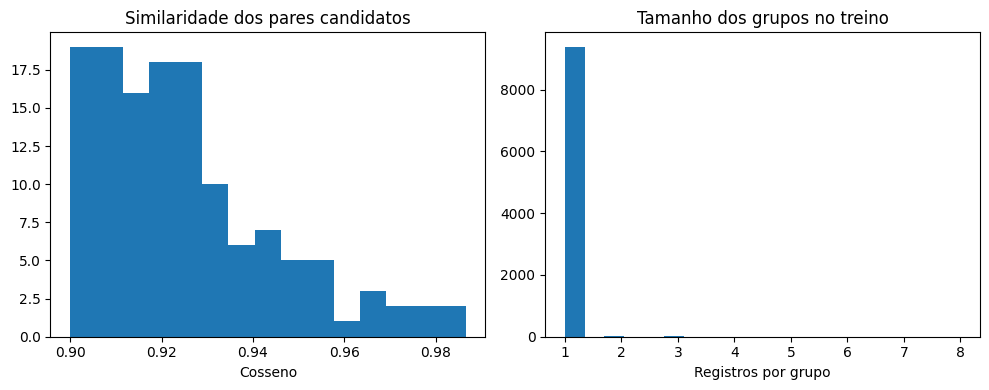

In [8]:
indices_treino = set(train.index)
pares_treino = pares_df.loc[pares_df.indice_a.isin(indices_treino) &
                           pares_df.indice_b.isin(indices_treino)].copy()


def sobreposicao_titulo(a, b):
    termos_a = set(normalize_text(a).split())
    termos_b = set(normalize_text(b).split())
    return len(termos_a & termos_b) / len(termos_a | termos_b) if termos_a | termos_b else 0.0


for sufixo in ["a", "b"]:
    ids = pares_treino[f"indice_{sufixo}"]
    for coluna in ["id_original", "Titulo", "label", "fonte_auditoria"]:
        pares_treino[f"{coluna}_{sufixo}"] = ids.map(df[coluna])
pares_treino["sobreposicao_titulo"] = [sobreposicao_titulo(a, b) for a, b in
    zip(pares_treino.Titulo_a, pares_treino.Titulo_b)]
pares_treino["rotulos_divergentes"] = pares_treino.label_a.ne(pares_treino.label_b)
pares_treino = pares_treino.sort_values("similaridade", ascending=False)
pares_treino.to_csv(REPORT_DIR / "pares_semelhantes_treino.csv", index=False)
display(pares_treino.head(20))
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(pares_treino.similaridade, bins=15)
axes[0].set_title("Similaridade dos pares candidatos")
axes[0].set_xlabel("Cosseno")
axes[1].hist(train.groupby("grupo_similaridade").size(), bins=20)
axes[1].set_title("Tamanho dos grupos no treino")
axes[1].set_xlabel("Registros por grupo")
salvar_grafico(fig, "04_similaridade")


## 8. Exportação e diagnóstico

O manifesto registra protocolo e parâmetros da separação. IDs e grupos são metadados; o 02 seleciona somente Titulo, Noticia e Autor. Os grupos do holdout são separados, mas as dobras internas do 02 ainda são estratificadas por registro: a independência entre essas dobras não é garantida. A auditoria não elimina automaticamente vereditos editoriais.


In [9]:
DATA_DIR.mkdir(parents=True, exist_ok=True)
cols = PROCESSED_COLUMNS + ["grupo_similaridade", "fonte_auditoria", "data_auditoria", "evento_auditoria"]
for name, frame in [("train.csv", train), ("test_holdout.csv", holdout)]:
    frame[cols].to_csv(DATA_DIR / name, index=False)
manifest = {"schema_version": SCHEMA_VERSION, "input_columns": FEATURE_COLUMNS,
    "label_names": LABEL_NAMES, "random_state": SEED, "input_policy": INPUT_POLICY,
    "manual_review_complete": False, "raw_sha256": sha256_file(RAW_PATH),
    "split": {"mode": SPLIT_MODE, "target_test_size": TEST_SIZE,
        "similarity_threshold": SIMILARITY_THRESHOLD, "neighbors": N_NEIGHBORS,
        "hashing_features": 2**18, "source_column": SOURCE_COLUMN, "date_column": DATE_COLUMN,
        "event_column": EVENT_COLUMN, "removed_boundary": removidos_fronteira,
        "n_train": len(train), "n_holdout": len(holdout)},
    "files": {name: sha256_file(DATA_DIR / name) for name in ["train.csv", "test_holdout.csv"]}}
(DATA_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2, ensure_ascii=False), encoding="utf-8")
qualidade.update({"n_treino": len(train), "n_holdout": len(holdout), "modo": SPLIT_MODE,
    "pares_candidatos_totais": len(pares_df), "pares_candidatos_treino": len(pares_treino),
    "manual_review_complete": False})
(REPORT_DIR / "resumo_auditoria.json").write_text(json.dumps(qualidade, indent=2,
    ensure_ascii=False), encoding="utf-8")
diagnostico = f"""# Diagnóstico do pré-processamento

Base original: {len(df_raw)} registros; retidos: {len(df)}. Treino: {len(train)}; holdout: {len(holdout)}.
Separação: {SPLIT_MODE}. Pares candidatos semelhantes no treino: {len(pares_treino)}.
Os grupos de similaridade detectados não atravessam as partições. Isso não garante ausência de eventos compartilhados ou paráfrases não detectadas.

Valores ausentes, autoria desconhecida, concentração de fontes e sinais editoriais estão registrados nas tabelas e gráficos do treino. Sem revisão manual integral, autor e texto podem revelar o processo de checagem. As métricas continuam exploratórias.

A avaliação estrutural das alternativas não compara desempenho preditivo. Fontes/eventos sem metadados suficientes ficam indisponíveis. Datas interpretadas automaticamente exigem atenção ao formato. As dobras internas do 02 ainda podem compartilhar fontes e grupos semelhantes; os resultados internos têm essa limitação. O holdout deve ser avaliado no 03 com o modelo congelado, sem ajustes guiados por suas métricas.
"""
display(Markdown(diagnostico))
(REPORT_DIR / "diagnostico.md").write_text(diagnostico, encoding="utf-8")
print("Partições:", DATA_DIR)
print("Auditoria e gráficos:", REPORT_DIR)


# Diagnóstico do pré-processamento

Base original: 11903 registros; retidos: 11902. Treino: 9518; holdout: 2384.
Separação: similaridade. Pares candidatos semelhantes no treino: 133.
Os grupos de similaridade detectados não atravessam as partições. Isso não garante ausência de eventos compartilhados ou paráfrases não detectadas.

Valores ausentes, autoria desconhecida, concentração de fontes e sinais editoriais estão registrados nas tabelas e gráficos do treino. Sem revisão manual integral, autor e texto podem revelar o processo de checagem. As métricas continuam exploratórias.

A avaliação estrutural das alternativas não compara desempenho preditivo. Fontes/eventos sem metadados suficientes ficam indisponíveis. Datas interpretadas automaticamente exigem atenção ao formato. As dobras internas do 02 ainda podem compartilhar fontes e grupos semelhantes; os resultados internos têm essa limitação. O holdout deve ser avaliado no 03 com o modelo congelado, sem ajustes guiados por suas métricas.


Partições: C:\Users\LAISA\OneDrive\Documentos\identificador-de-fake-news\notebooks\v2_validacao_externa\data\processed\texto_autor_exploratorio_v4
Auditoria e gráficos: C:\Users\LAISA\OneDrive\Documentos\identificador-de-fake-news\reports\v2_stacking_texto_autor_exploratorio\preproc_eda
